# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [32]:
import pandas as pd

alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')

questions = alldata.drop(['navn', 'parti', 'storkreds', 'alder'], axis = 'columns')

display(questions)

tv2q.rename(columns = {'id': 'ID', 'question' : 'Question'}, inplace = True)
questions_text = pd.concat([drq, tv2q], ignore_index = True)
questions_text = questions_text[['ID', 'Question']]
questions_text.set_index('ID', inplace = True)
questions_text.index = questions_text.index.astype(str)

display(questions_text)

,530,531,533,534,535,537,538,540,541,543,...,8a,8b,9a,9b,10a,10b,11a,11b,12a,12b
0,-1,-2,1,-2,2,1,-2,1,1,2,...,1,0,2,0,1,-2,-2,1,1,1
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,0,0,-2,0,-1,2,1,-2,0,0
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,1,1,-1,-2,0,2,0,-1,1,-2
3,2,1,-2,-1,1,1,1,1,1,-2,...,2,2,-2,2,2,2,2,-1,2,0
4,1,1,-2,2,-2,1,-2,1,2,-2,...,1,0,-2,0,-1,0,-2,0,2,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,1,1,1,-2,2,-1,1,-2,1,1,...,2,1,1,2,-1,2,1,-2,0,0
863,1,-2,-2,-2,1,-2,-1,-2,-2,-2,...,1,0,-1,0,-1,2,2,-2,0,0
864,1,1,1,-2,2,-1,1,-1,-1,1,...,1,0,-1,0,-1,2,2,-2,0,1
865,1,-1,1,-2,1,-1,-1,-1,-1,1,...,0,0,0,0,0,2,1,-2,1,0


,Question
ID,
530,Danmark skal bruge flere penge på at styrke to...
531,Der skal indføres en særlig skat på de allerhø...
533,Kriminalitet begået i udsatte boligområder ska...
534,På sigt skal Danmark meldes ud af EU
535,"Det er fornuftigt, at Danmark i de kommende år..."
537,"Det er okay, at den økonomiske ulighed stiger,..."
538,Forældres indkomst skal være et af kriterierne...
540,Det skal være muligt at tjene penge på at driv...
541,Der skal indføres skat på fortjenesten ved sal...


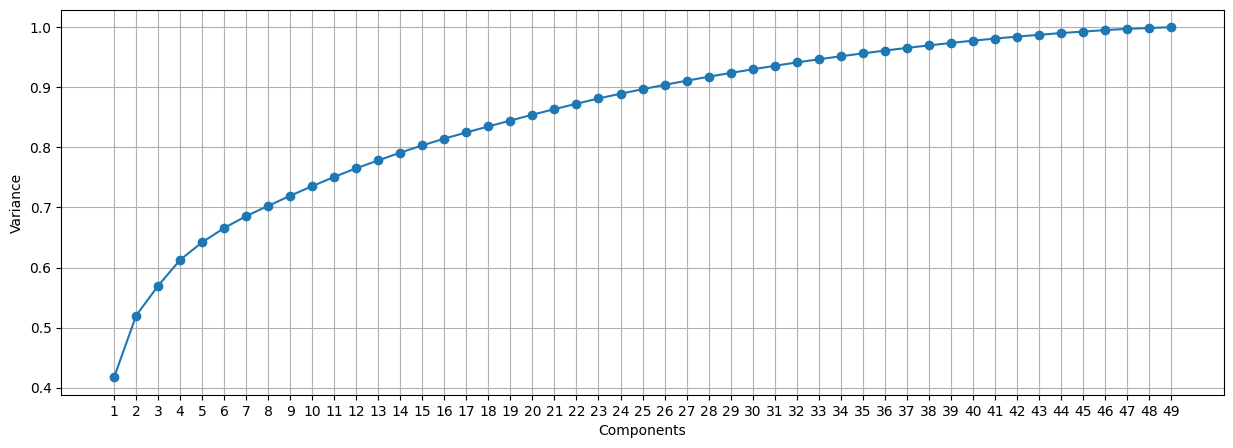

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
questions_scaled = scaler.fit_transform(questions)

pca = PCA()
questions_pc = pca.fit_transform(questions_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(15, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Components')
plt.ylabel('Variance')
plt.xticks(np.arange(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.show()


In [43]:
components = questions_pc[:, :15]

In [47]:
loadings = pd.DataFrame(
    pca.components_[:15].T,
    index = questions.columns,
    columns = [f'PC{i+1}' for i in range(components.shape[1])]
)

top_questions = []

for i in range(components.shape[1]):
    pc_label = f'PC{i+1}'
    top_idx = loadings[pc_label].abs().idxmax()
    question_text = questions_text.loc[top_idx, 'Question']
    print(f"Top question for {pc_label} (Q# {top_idx}): {question_text}")
    if top_idx not in top_questions:
        top_questions.append(top_idx)

print(top_questions)



Top question for PC1 (Q# 530): Danmark skal bruge flere penge på at styrke tog- og busdrift frem for at bygge nye motorveje
Top question for PC2 (Q# 10b): Den såkaldte Arne-pension, der giver mulighed for tidligere pension, skal bibeholdes, selvom der er mangel på arbejdskraft.
Top question for PC3 (Q# 534): På sigt skal Danmark meldes ud af EU
Top question for PC4 (Q# 5b): Der bør tilføres ekstra ressourcer til ældreplejen, selvom dette vil medføre, at andre velfærdsområder får færre ressourcer.
Top question for PC5 (Q# 547): Der bør dannes en regering hen over midten
Top question for PC6 (Q# 9b): Skolerne skal i højere grad hjælpe særligt udfordrede børn, også selvom det vil ske på bekostning af hjælpen til de øvrige elever.
Top question for PC7 (Q# 12a): Hvis coronasmitten stiger markant til vinter, skal samfundet holdes mest muligt åbent, også selvom det kan koste menneskeliv.
Top question for PC8 (Q# 5a): Det er nødvendigt at indføre brugerbetaling i ældreplejen for at sikre, at d

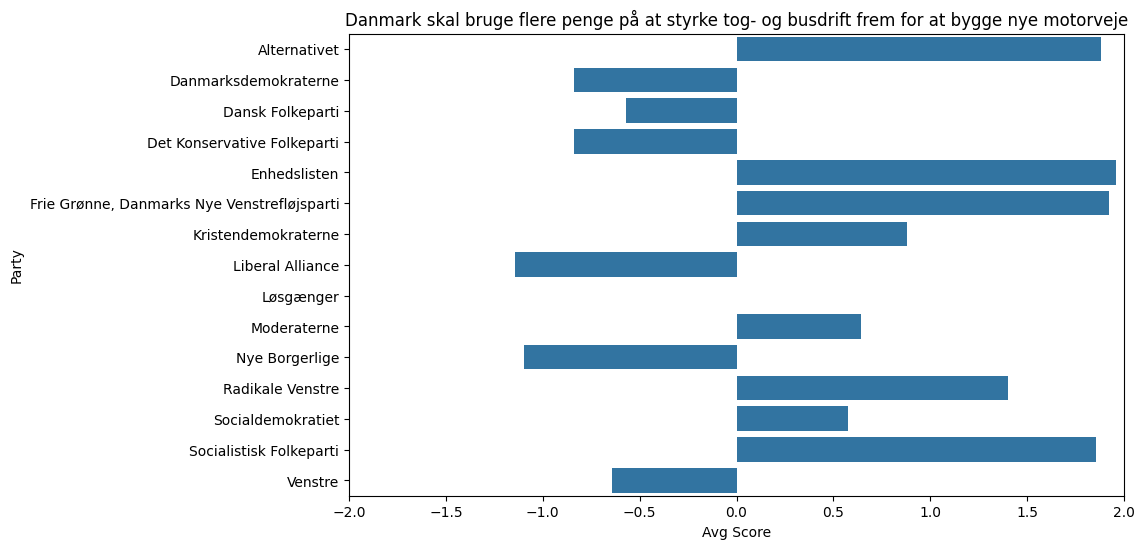

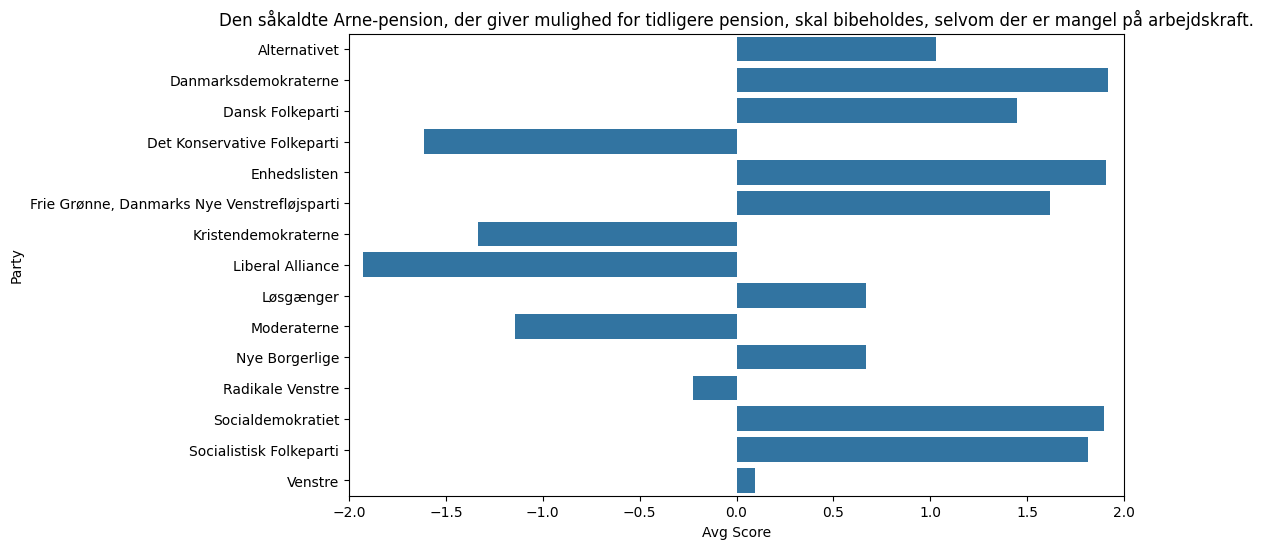

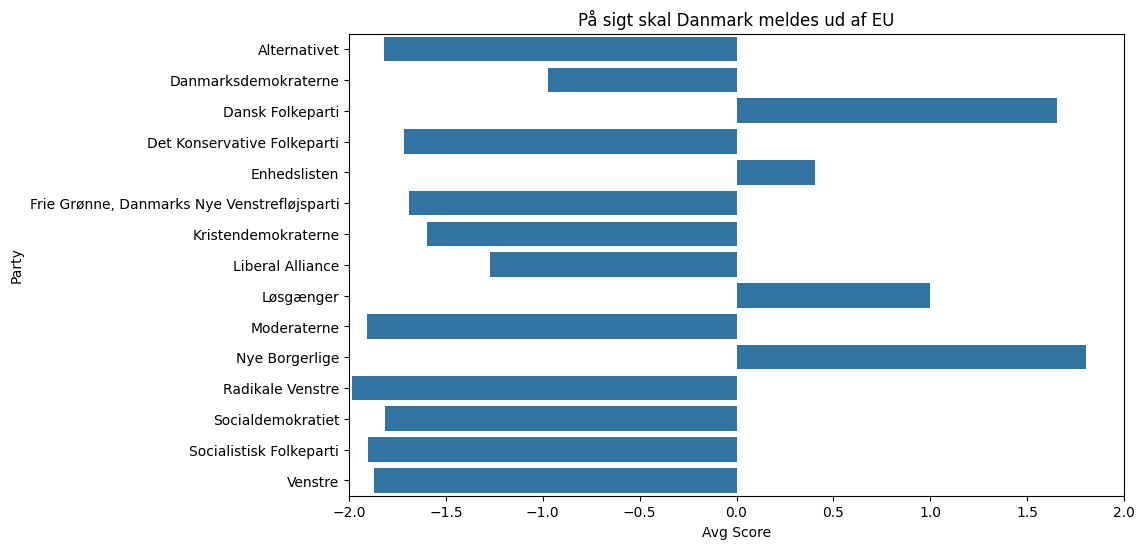

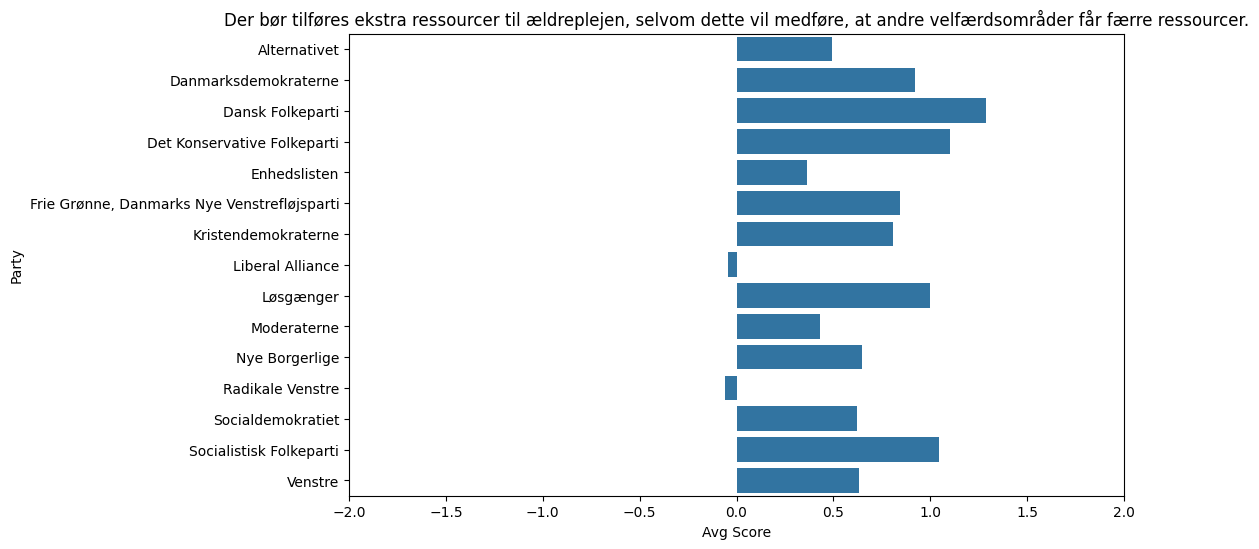

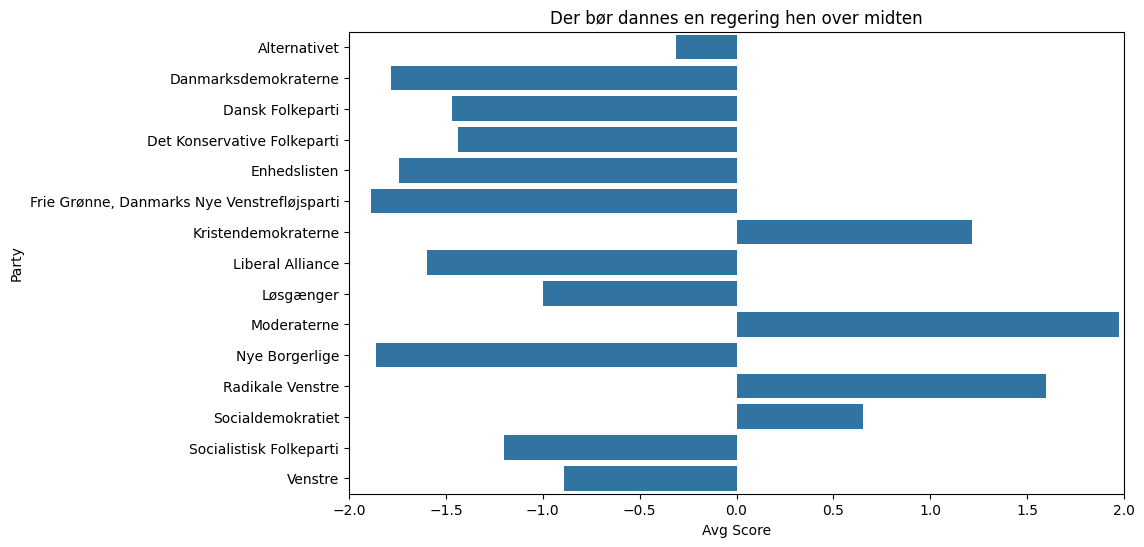

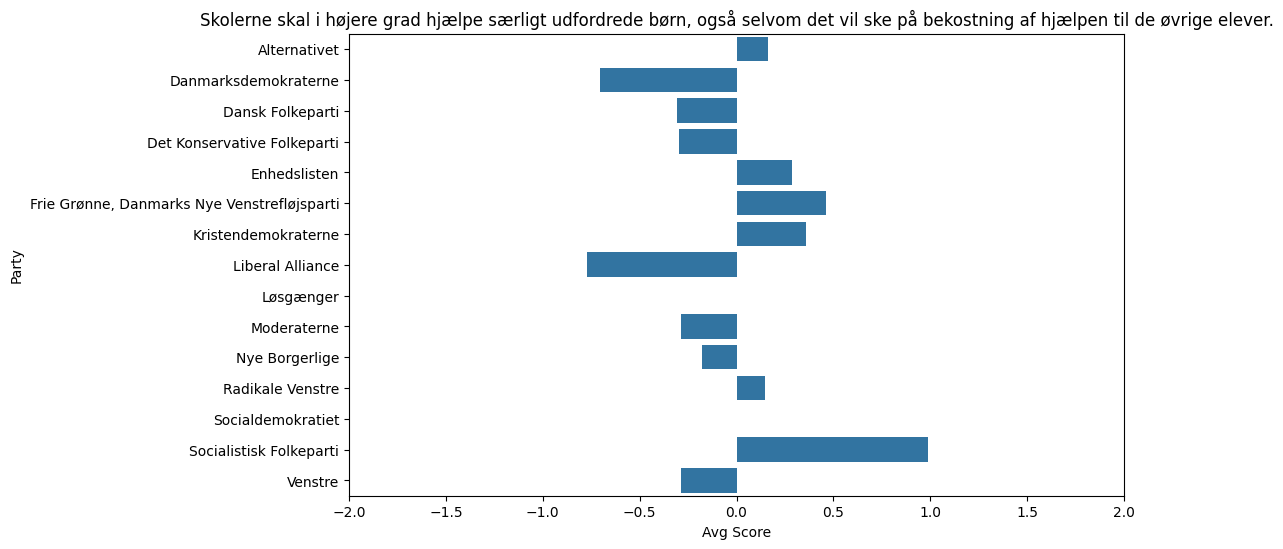

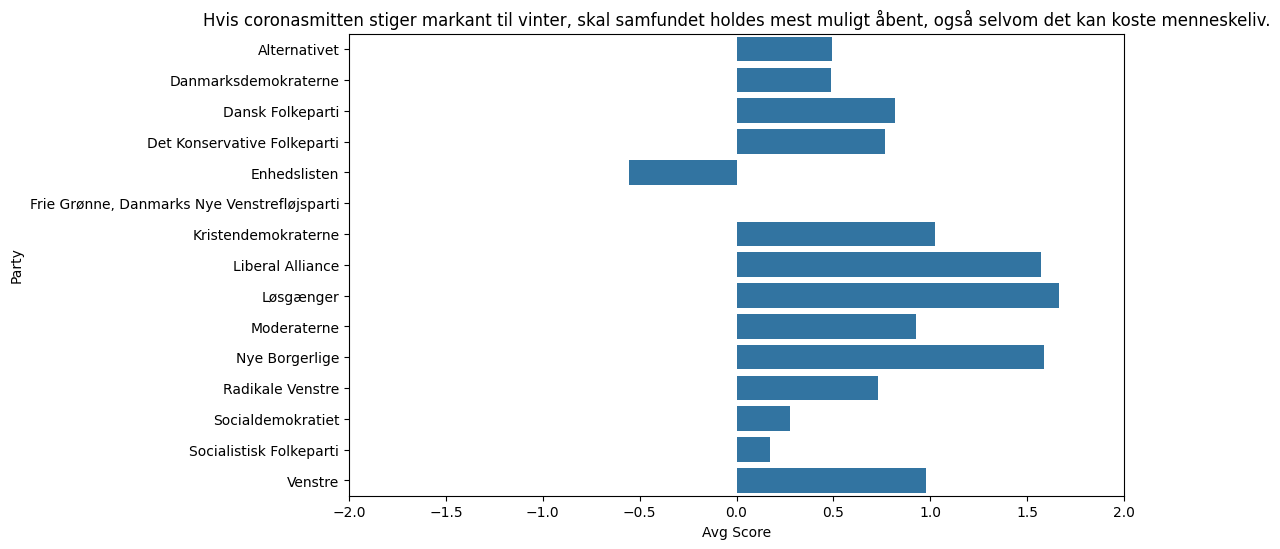

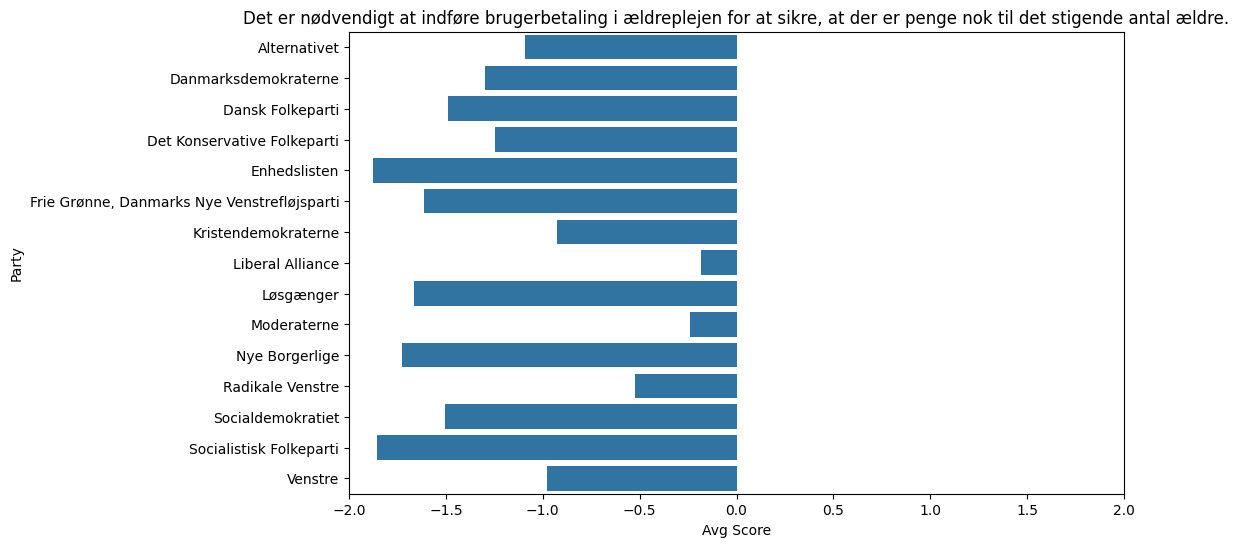

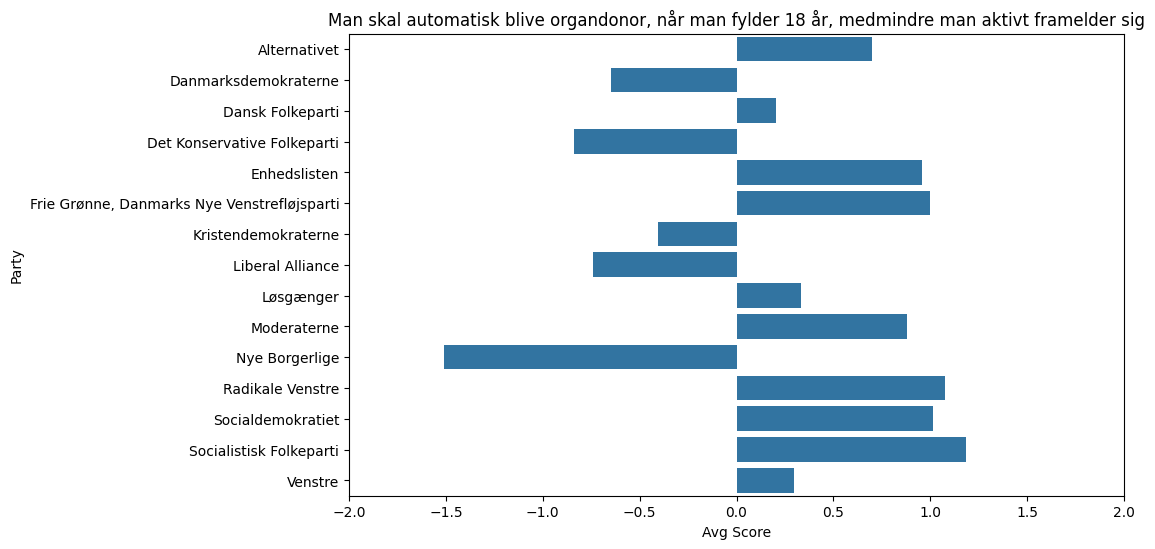

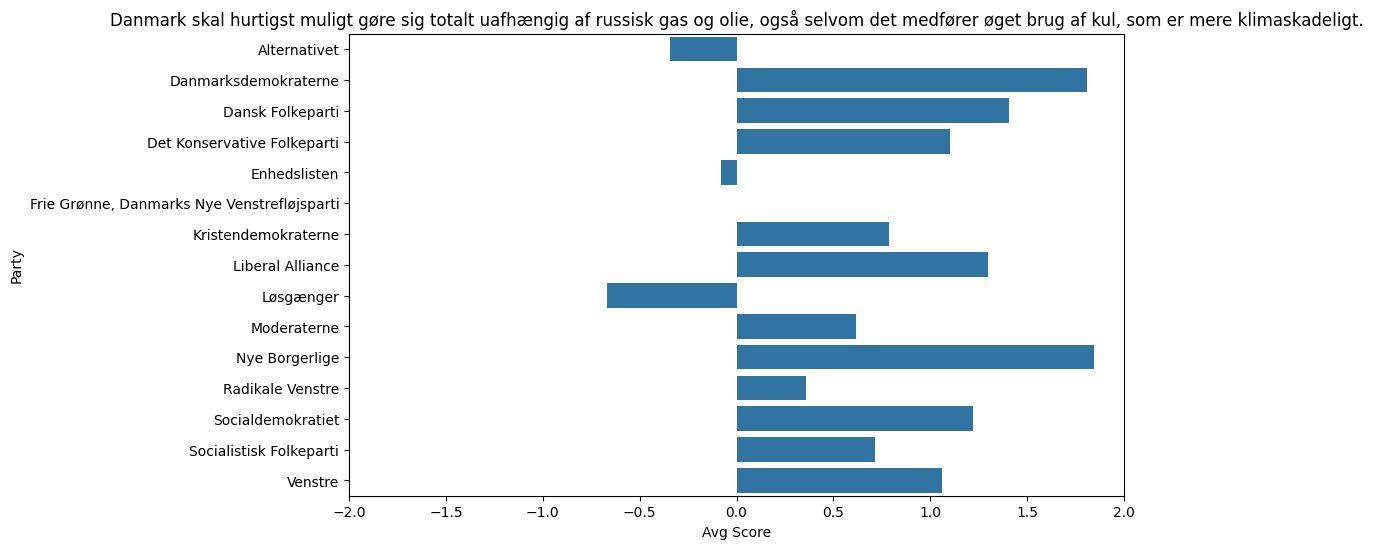

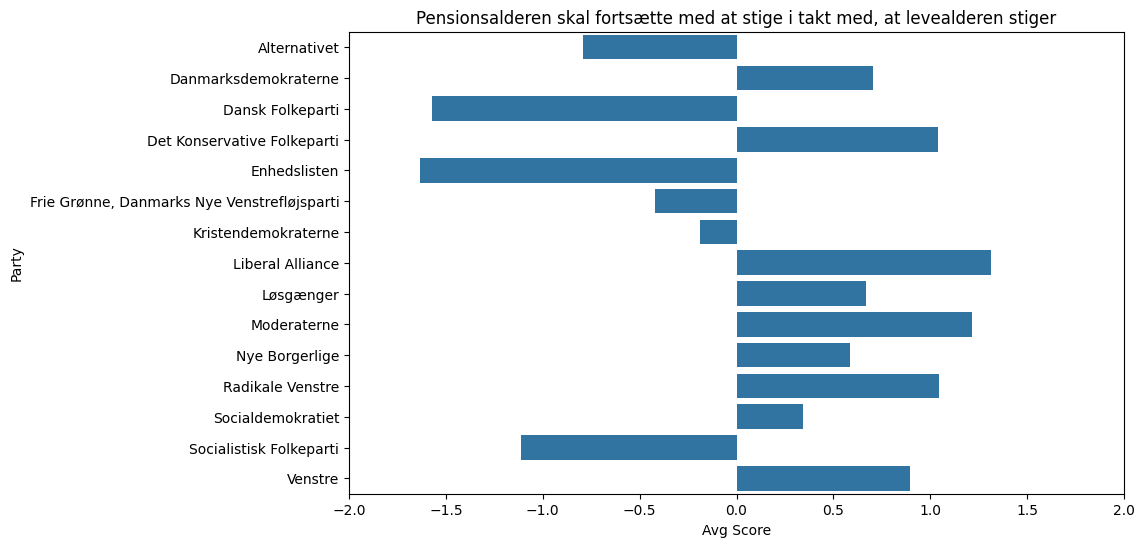

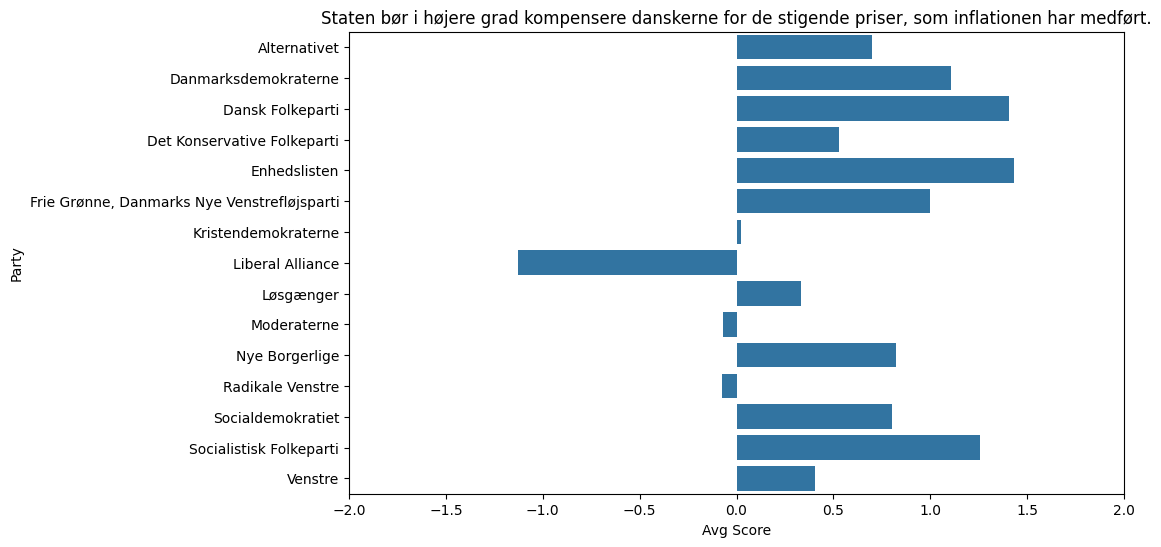

In [48]:
import seaborn as sns

party_avg = alldata.groupby('parti')[questions.columns].mean()

for idx in top_questions:
    question_text = questions_text.loc[idx, 'Question']
    avg_scores = party_avg[idx].sort_values()

    plt.figure(figsize = (10, 6))
    sns.barplot(y = party_avg.index, x = party_avg[idx])
    plt.title(question_text)
    plt.ylabel("Party")
    plt.xlabel("Avg Score")
    plt.xlim([-2, 2])
    plt.show()

### Clustering

#### kMeans

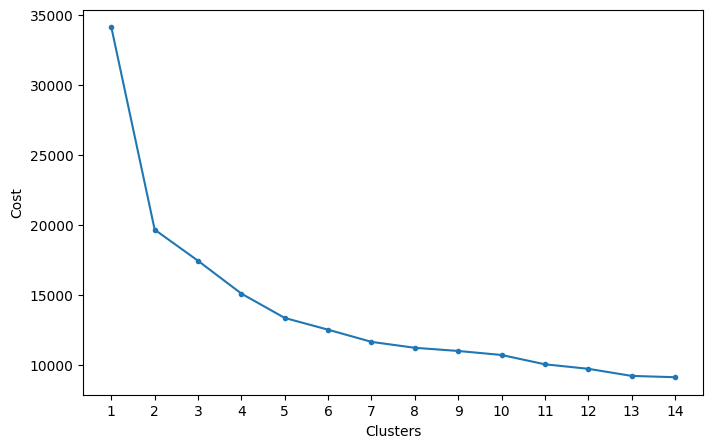

In [49]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
    kmeans.fit(questions_pc[:, :15])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, '.-')
plt.xlabel('Clusters')
plt.ylabel('Cost')
plt.xticks(k_range)
plt.show()

Kinda ambiguous... I will pick 5.

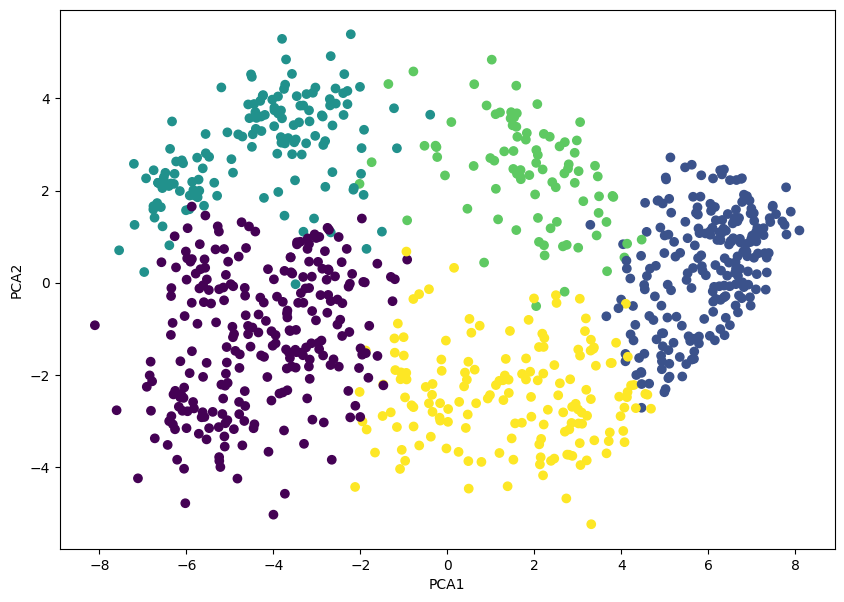

In [50]:
k = 5

kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
cluster_labels = kmeans.fit_predict(questions_pc[:, :15])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(questions_pc[:, :15][:, 0], questions_pc[:, :15][:, 1], c = cluster_labels)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

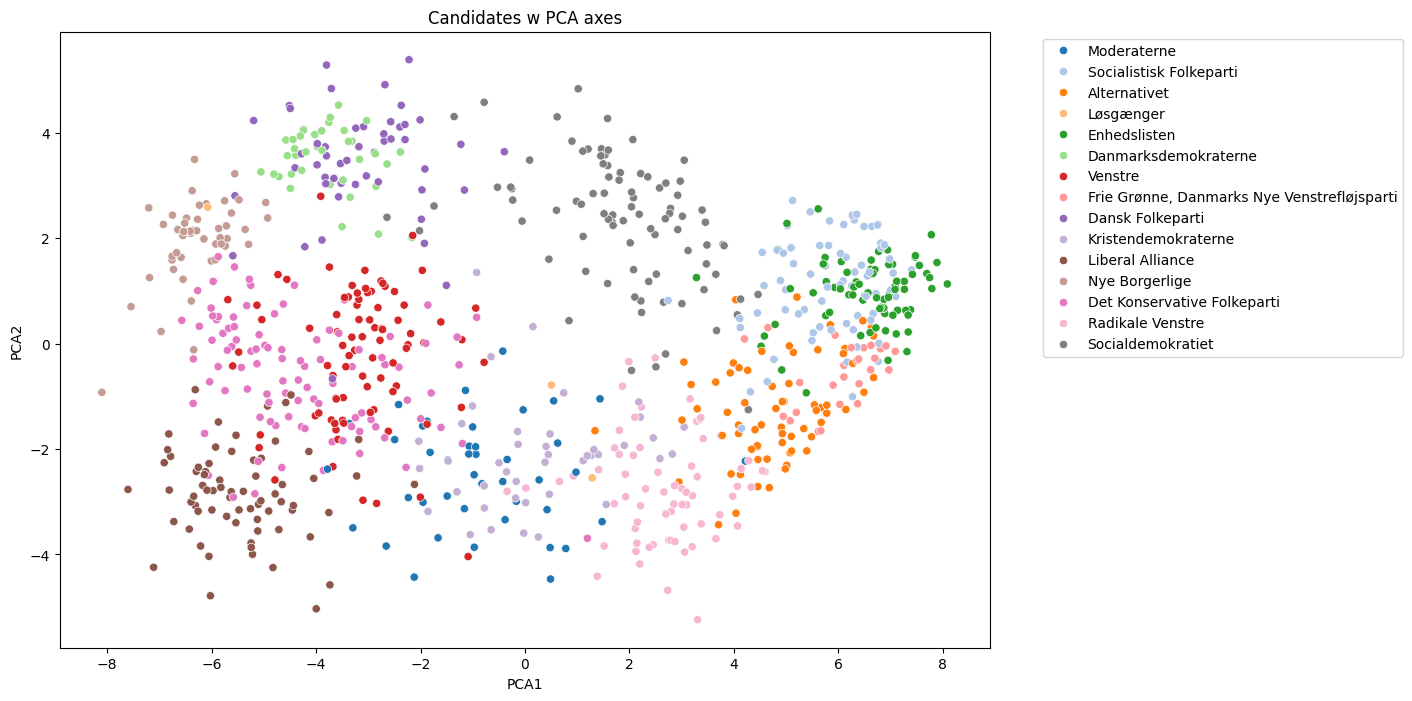

In [51]:
candidate_parties = alldata['parti']
cluster_df = pd.DataFrame({
    'PCA1': components[:, 0],
    'PCA2': components[:, 1],
    'Cluster': cluster_labels,
    'Party': candidate_parties.values
})

plt.figure(figsize = (12, 8))
sns.scatterplot(data = cluster_df, x = 'PCA1', y = 'PCA2', hue = 'Party', palette = 'tab20')
plt.title('Candidates w PCA axes')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

PCA1 seems to plot societal values, with conservatism on the left and liberalism on the right.  Ex - Nye Borgerlige and Enhedslisten have similar y-values, but polar opposite wings.

PCA2 seems to cover economic values. Ex - Liberal Alliance and Danmarksdemokraterne are both right-wing parties but seem to disagree (or have differing intensity) on some questions related to economic inequality.

#### Hierarchical Clustering

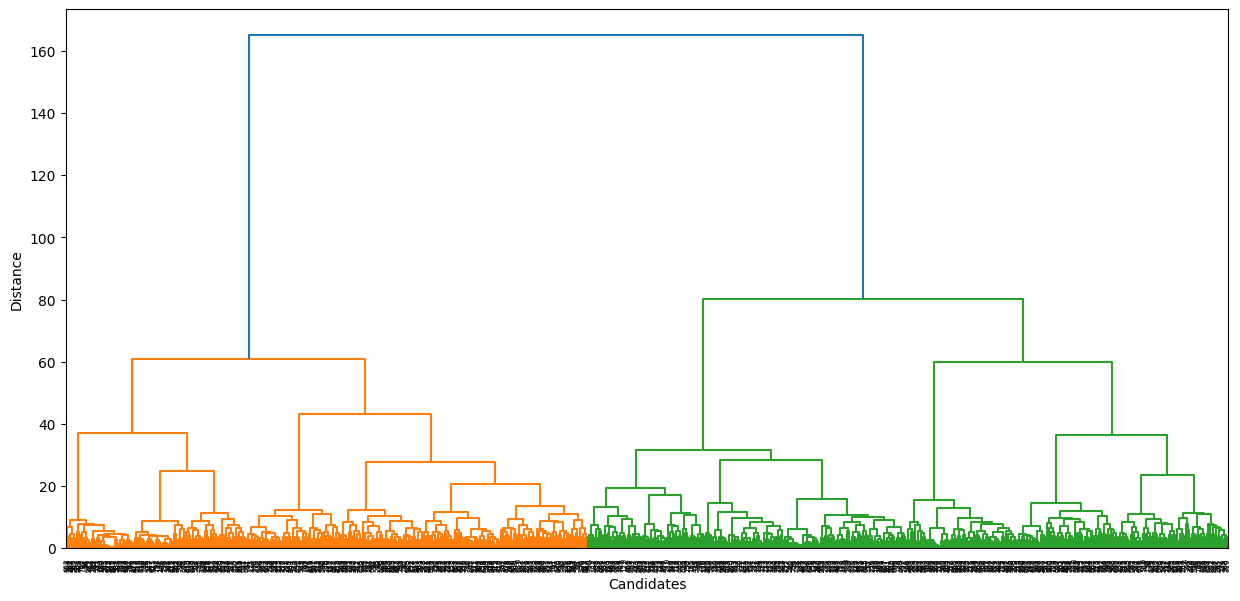

In [52]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(components, method = 'ward')

plt.figure(figsize = (15, 7))
dendrogram(linkage_matrix, truncate_mode = 'level')
plt.xlabel('Candidates')
plt.ylabel('Distance')
plt.show()

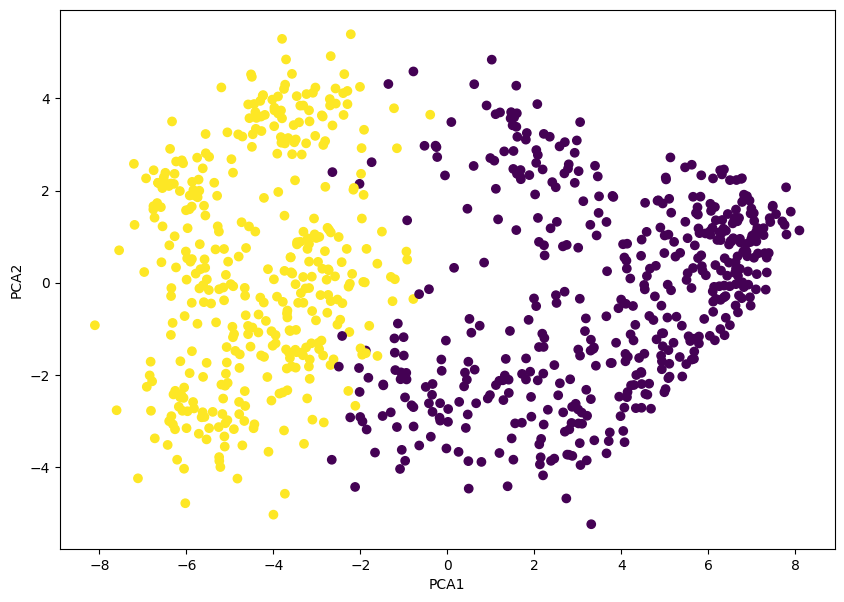

In [53]:
from sklearn.cluster import AgglomerativeClustering

k = 2

agglo = AgglomerativeClustering(n_clusters = k, linkage = 'ward')
agglo_labels = agglo.fit_predict(components)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(components[:, 0], components[:, 1], c = agglo_labels)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

DBSCAN

In [1]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors = components.shape[1] * 2)
neighbors_fit = neighbors.fit(components)
distances, indices = neighbors_fit.kneighbors(components)

distances = np.sort(distances[:, components.shape[1] * 2 - 1])
plt.figure(figsize = (5, 5))
plt.plot(distances)
plt.xlabel('Points by distance')
plt.ylabel('30th Nearest Neighbor')
plt.grid(True)
plt.show()

display(distances)

KeyboardInterrupt: 

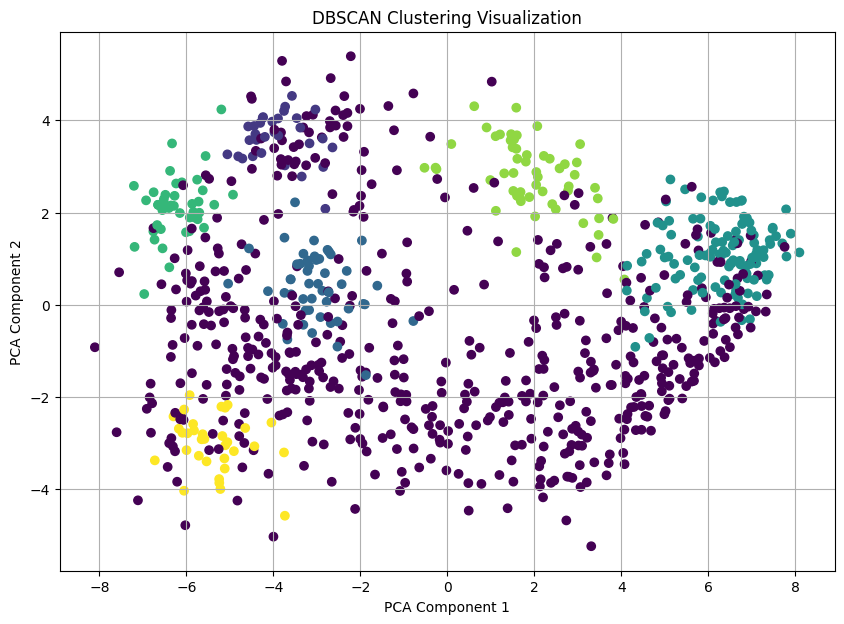

In [79]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 3.1, min_samples = components.shape[1] * 2)
dbscan_labels = dbscan.fit_predict(components)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(components[:, 0], components[:, 1], c = dbscan_labels)

plt.title('DBSCAN Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()